## From the Algebra of Unsupervised Statistics to Deep Learning
**1. Fitting Various Curves Using Artificial Neural Network**  
Previously discussed PCA, CA, CCA and some other clustering methods used in, for example, population stratification of genetic like STRUCTURE and admixture are almost all belong to unsupervised learning. 
Compare to supervised learning that need to mark trainning data to know the output y corresponding input (x1,x2,...), it only know the input and learn the inherent patterns within the data.

We can also abtain the parameters of an Artificial Neural Network (ANN) through supervised learning or unsupervised learning, i.e. deeplearning. We've shown that the methods like PCA,RDA are essentially fitting to linear response and CA,CCA are fitting to Gaussan or unimodal curve. Now we can also utilize neural network to fit all kinds shape of curves theoretically.  
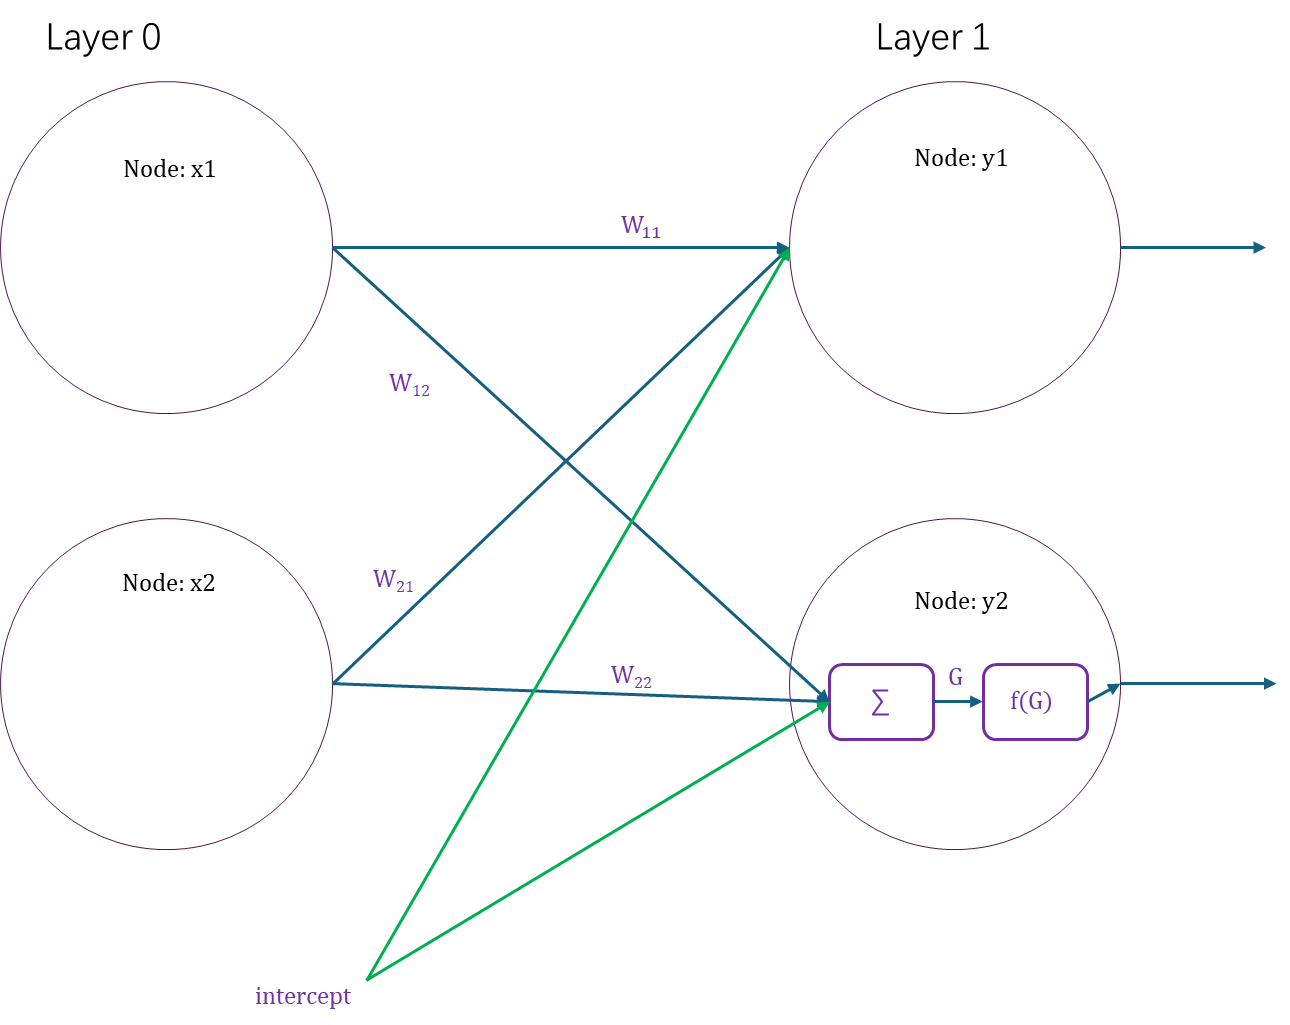  
      Fig. 4.1

Artifical neural network is essentially a hierarchical directed graph as the fig 4.1 (consist of two layers for example) shows and every neuron (i.e. nodes in fig represented by circles) just do two things (as detailed in the Node y2 in fig 4.1):  
1. weight sum all its input data (i.e. the connected edges. The output of the previous layer is fed as input to the current layer)  
2. use a function, called activation function, to transform the weighted sum into its output. (analog to step function in biology).  

For example, we use it to do logical 'and'  
0 and 0 = 0  
1 and 0 = 0  
0 and 1 = 0  
1 and 1 = 1  
We can define the node x1 and x2 to receive the two input bits respectively and the node y1 as output. We set both the W₁₁,W₂₁ to be 0.33, then use a piecewise function that output 1 when the weighted sum is bigger than 0.5 and output 0 when the weighted sum is smaller than 0.5. We can also easily fit a straight line, e.g. 0.3x+2.3y=-1, by setting the W₁₁, W₂₁ to be 0.3 and 2.3 respectively, with bias=1.(ignore node y2)  
In Artificial Intelligence systems, diverse entities – including words, sentences, images, and other data forms – are fundamentally mapped to points in high-dimensional vector spaces. This representation enables mathematical operations (such as vector addition or similarity measurement) to perform classification, reasoning, and semantic understanding tasks. In an example from < The Beauty of Mathematics >, we know that in the issue of speech recognition, establishing an acoustic model based on "consonants and vowels" are required. Every consonant or vowel corresponds to a cluster of data that are represented by points in high-demension spaces. Recognizing those sounds is actually dividing some areas in this multi-dimensional space, so that each sound belongs to a different area. For example, suppose there are only two dimensioins in space show as Fig. 4.2 left, to distinguish 'a' and 'e', one can use a straight line with 'a' on the left and 'e' on the right.  
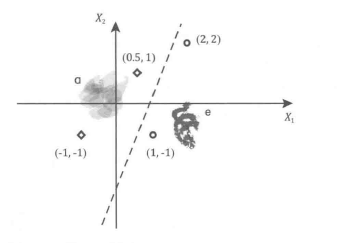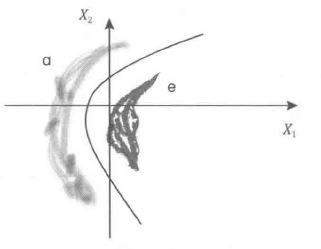  
Fig. 4.2  Pattern distribution map of vowels 'a' and 'e' (Two-dimensional simulation)  
We can use an ANN to implement a linear classifier as we just discussed. Setting the W₁₁=3, W₂₁=-1 and the bias(intercept)=2, when new voice data come in, if the output is greater than 0, it belong to 'e', otherwise 'a'. it can be regarded as the inner product of the input vector and the weight vectors of each directed arc.  
What if some more complex situations, like fig. 4.2 right that can not be distinguished through a straight line, but a curve can be used.  
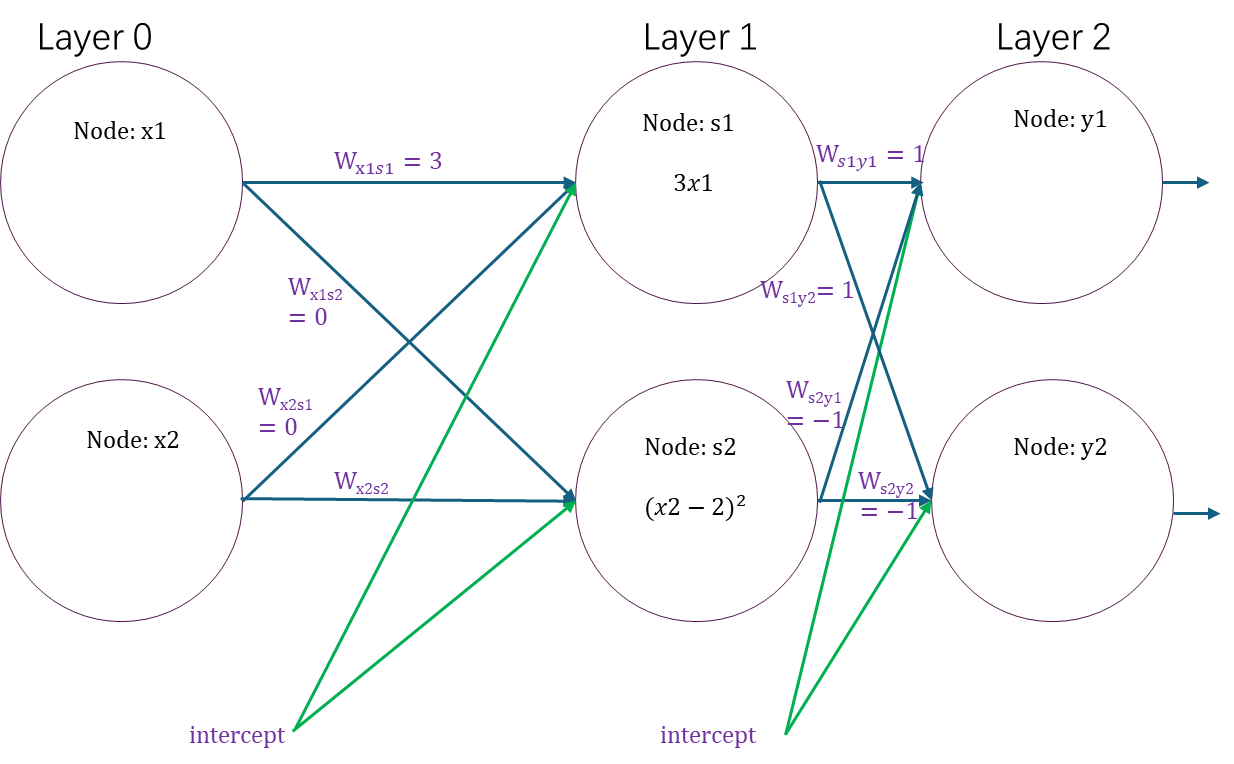  
Fig. 4.3  
As illustrated in fig. 4.3, a nonlinear activation function, square function, was applied to achive the curve. Fig. 4.3 neural network actually obtained a classifier that the boundary being a curve as below:  
3x=(y-2)+2  
In practice, the activation functions of hidden layers are usually nonlinear and the number of layers in the hidden layer and the number of neurons in each layer are predefined. What function can be an activation function? if allow any kinds of functions, the achieved classifiers would be too flexiable to make ANN loss generalization capability. In order to unify the standards, it is stipulated that the neuron function can only perform one nonlinear transformation by taking one input variable that is the result of the linear combination of its inputs:  
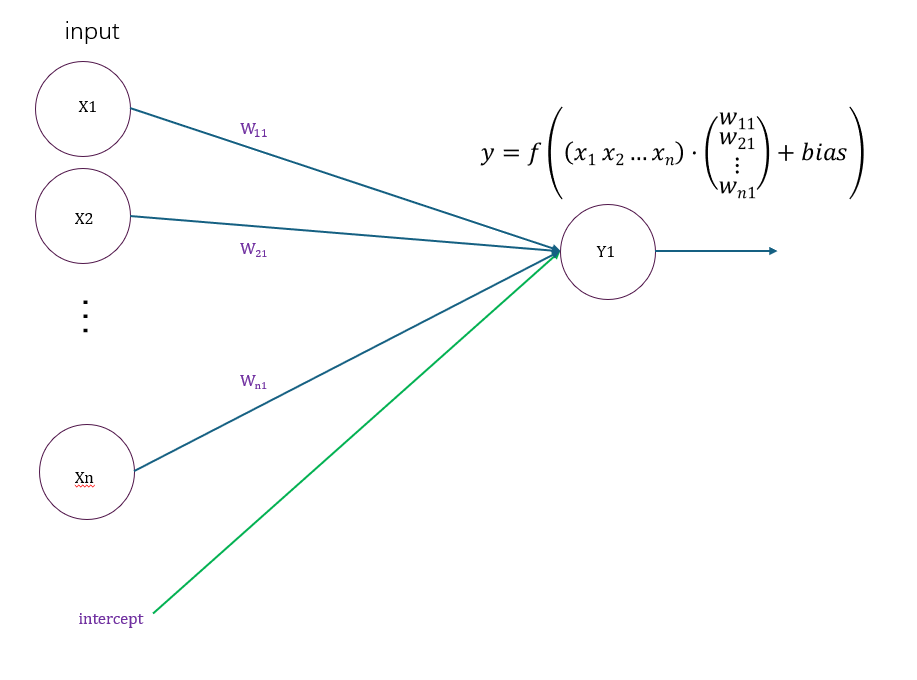  
Fig. 4.4  
For example, a node Y1 has input nodes X1,X2,...,Xn with value x₁,x₂,...,xₙ, and the corresponding weights of the arcs are W₁,W₂,...,Wₙ, respectively. The output y=f(G) and G is the linear combination of input vector and weight vector.  So far, it seems that all the details are understandable and could be described mathematically, whereas as the number of hidden layers increase and some other specialized architectures (e.g. FNNs,CNNs) are incorporated, ANN became unintelligible black boxes. And such multiple layers models are very similar to the Boltzmann machine in statistical physics, and the algorithms of artificial intelligence may have been inspired by physics. Similarly, the brain-inspired mechanism closely links artificial intelligence to fundamental questions in physics and complex systems, which have contributed to Hopfield and Hinton's work on AI to be awwarded the 2024 Nobel Prize.  
The commonly use activation functions are log(G), (G)<sup>2</sup>, e<sup>G</sup> and rectified linear unit (ReLU).  
To get parameters of the model, i.e. the values of weight matrix, ANNs can learn through supervised or unsupervised training. Supervised trainning need labeled data,(Xᵢ,Yᵢ). To train the network, we intuitively need to compare the predictions with the true value. There are two similar concepts that are used to do such compare, loss function and cost function. The loss function,L(f(X),Y), is defined on a single training sample, that is, it is regarded as the error of one sample. Squared error (especially relevant when the output is a continuous value) and cross-entropy (measure the difference between two probability distributions over the same set of underlying events or classes, as is appropriate when the output is categorical) are commonly used as loss function.[ref] The cost function is defined on the entire training set, that is, the average of the sum of errors of all samples, that is, the average of the sum of the loss functions. Whether there is this average or not actually does not affect the solution result of the final parameters. <font color = red>By updating the weights in a small step in the direction of the derivative, the network's prediction loss can be decreased, and its accuracy can be increased. The derivative can be efficiently computed for each training point via the chain rule from calculus; this process is commonly called</font> **back-propagation**.  


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  
#or
model.fit() #

Somethims the cost function is Empirical Risk when it applied on trainning data. Training process require the object function to be minimal that is require both empirical risk and structure risk to be minimal. i.e. min $\frac{1}{N}\sum_{i = 1}^{N}{L(f(xᵢ),yᵢ)+λJ(f)}$  正则化  
see an example. We have a data with distribution: y=0.5x³-2x²+x+noise  
use PyTorch with ReLU activation function to design and implement an ANN to fit the data(tranning),then predict new values.
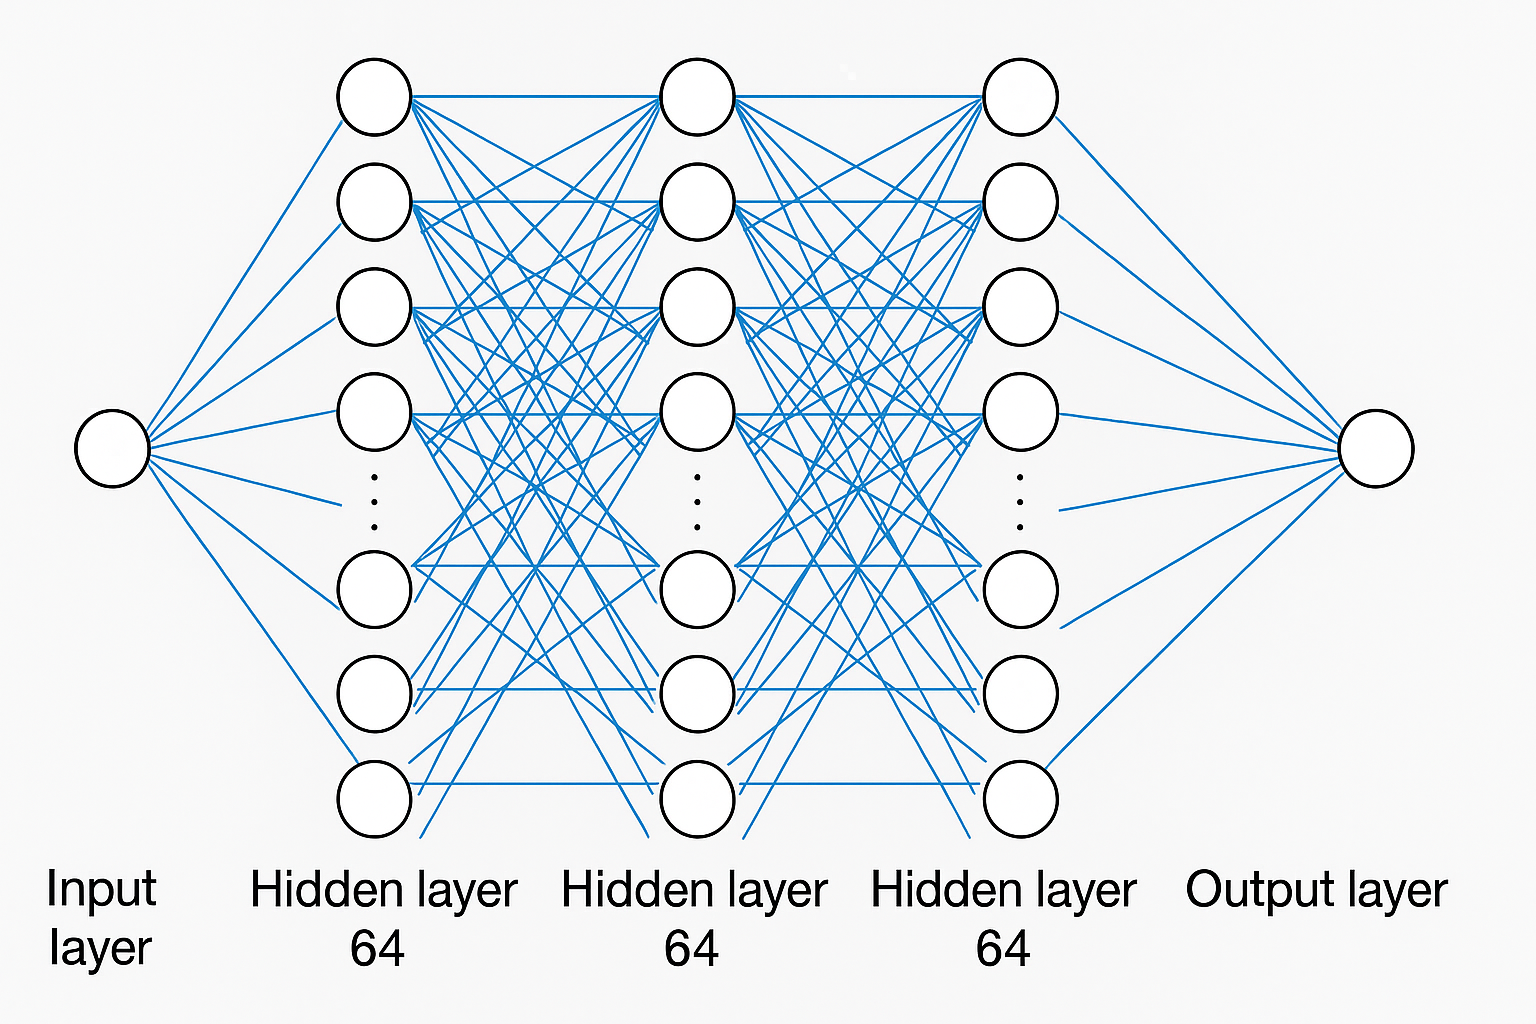  

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
# 生成训练数据
x = np.linspace(-2, 3, 100)
y = 0.5 * x**3 - 2 * x**2 + x + np.random.normal(0, 1, size=x.shape)
# 转为 PyTorch Tensor
x_train = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
# 构建简单神经网络模型,该网络是一个有3层的FNN
model = nn.Sequential(
    nn.Linear(1, 64),#线性组合
    nn.ReLU(),#激活函数
    nn.Linear(64, 64),
    nn.ReLU(),#第二层激活函数
    nn.Linear(64, 1)#输出层
)
# 定义损失函数和优化器
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

As nn.Linear(input_dim,output_dim) require the input is two-dimension data, which the first dim is the data size (100 in this example) and the 2nd is number of features (one feature here). so use .unsqueeze(1) transfer [,,,] to [[],[],,,[]]  
nn.Linear represent a linear combination:  ${xW_{input\_dim×output\_dim}}^⊤+b$. Transfer every input,x, to 64 dim space. do 100 times. 

In [ ]:
# 定义损失函数和优化器
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# 训练模型
for epoch in range(1000):
    model.train()
    pred = model(x_train)
    print(pred)
    loss = loss_fn(pred, y_train)
    #这里就是训练的核心，梯度下降的程序实现代码
    optimizer.zero_grad()#每次反向传播的梯度是累加的，所以必须先清空旧的梯度。
    loss.backward()#求偏导数 反向传播（backpropagation）
    optimizer.step()#用导数更新参数

The common Loss/cost function is Mean Squared Error: $\sum_{i = 1}^{N}{(f(xᵢ)-yᵢ)²}$, N is the batch_size=100  ,which can be implement using nn.MSELoss().  
(or use Corss-Entropy as cost function: $\sum_{i = 1}^{N}{-f(xᵢ)log(yᵢ)}$ )   
loss.backward() 对每个参数计算成本/损失函数的偏导：$\frac{\partial L}{\partial θ}$， θ would be W and b respectively for MSE.  
optimizer.step()根据上一步计算的偏导数，更新参数θ。 此处用的前面代码指定的Adam算法，还有 SGD 等算法
θ←θ−α⋅$\frac{∂Loss}{∂θ}$ 

In [ ]:
# 可视化结果
model.eval()
y_pred = model(x_train).detach().numpy()

plt.scatter(x, y, label='Data')
plt.plot(x, y_pred, color='red', label='NN Fit')
plt.legend()
plt.title("NN fitting y = 0.5x^3 - 2x^2 + x")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

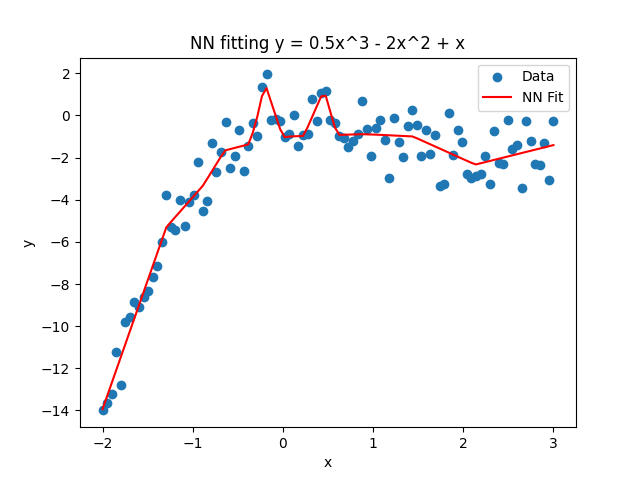  
This way we acually fit the curve using piecewise linear function if we use ReLU as activated function.  
单靠 nn.Linear 是线性的，不能拟合曲线，但如果加上非线性激活函数（比如 ReLU）： 
nn.Sequential(  
  nn.Linear(1, 64),  
  nn.ReLU(),  
  nn.Linear(64, 1)  
)  
就能组成类似y=a⋅max(0,xW₁+b₁)W₂+b₂  
分段线性函数可以表示为两层LNN，但我无法找到总结解释较好的相关的论文，有知道的希望可以发给我感谢 ruiliugenetic@gmail.com